In [97]:
import numpy as np
import matplotlib.pyplot as plt
from uncertainties import ufloat
from uncertainties import unumpy
from scipy import odr

sigma_master = 3 # mm

# Focal length from Object and Image Distance

In [98]:
data_OID = np.loadtxt('FL_OID.txt', delimiter=',')
sigma_OID = 0.5 # mm
lens_1_OID = unumpy.uarray(data_OID[:3], sigma_master)
lens_2_OID = unumpy.uarray(data_OID[3:6], sigma_master)

def f_OID(lens):
    a = lens[:, 0]
    b = lens[:, 1]
    return (a * b) / (a + b)

f_1 = f_OID(lens_1_OID)
f_2 = f_OID(lens_2_OID)

mean_1 = f_1.mean()
mean_2 = f_2.mean()

################################
# table with help from CHATGPT #
################################

table = r"""\begin{table}[h]
\centering
\begin{tabular}{l c}
\hline
Measurement & $f = \frac{ab}{a+b}$ \\
\hline
"""

for i, val in enumerate(f_1):
    table += f"Lens 1 -- {i+1} & ${val:.2uL} \\mathrm{{mm}}$ \\\\\n"
table += f"Lens 1 -- Mean & ${mean_1:.2uL} \\mathrm{{mm}}$ \\\\\n"
table += r"\hline" + "\n"

for i, val in enumerate(f_2):
    table += f"Lens 2 -- {i+1} & ${val:.2f} \\mathrm{{mm}}$ \\\\\n"
table += f"Lens 2 -- Mean & ${mean_2:.2uL} \\mathrm{{mm}}$ \\\\\n"
table += r"\hline" + "\n"

table += r"""\hline
\end{tabular}
\caption{Focal lengths with propagated uncertainties}
\end{table}
"""

print(table)

\begin{table}[h]
\centering
\begin{tabular}{l c}
\hline
Measurement & $f = \frac{ab}{a+b}$ \\
\hline
Lens 1 -- 1 & $39.6 \pm 2.7 \mathrm{mm}$ \\
Lens 1 -- 2 & $42.9 \pm 2.1 \mathrm{mm}$ \\
Lens 1 -- 3 & $45.1 \pm 2.4 \mathrm{mm}$ \\
Lens 1 -- Mean & $42.5 \pm 1.4 \mathrm{mm}$ \\
\hline
Lens 2 -- 1 & $112.47+/-1.11 \mathrm{mm}$ \\
Lens 2 -- 2 & $136.36+/-1.09 \mathrm{mm}$ \\
Lens 2 -- 3 & $148.03+/-1.26 \mathrm{mm}$ \\
Lens 2 -- Mean & $132.29 \pm 0.67 \mathrm{mm}$ \\
\hline
\hline
\end{tabular}
\caption{Focal lengths with propagated uncertainties}
\end{table}



# Focal length using Bessel's Method

In [99]:
data_BM = np.loadtxt('FL_BM.txt', delimiter=',')
sigma_BM = 0.5
lens_1_BM = unumpy.uarray(data_BM[:2], sigma_master)
lens_2_BM = unumpy.uarray(data_BM[2:], sigma_master)

def f_BM(lens):
    d = lens[0]
    a = lens[1]
    b = lens[2]
    e = b - a
    return (d**2-e**2)/(4*d)

f_1_BM = f_BM(lens_1_BM[0])
f_1p_BM = f_BM(lens_1_BM[1])
f_1_mean = np.mean([f_1_BM, f_1p_BM])

f_2_BM = f_BM(lens_2_BM[0])
f_2p_BM = f_BM(lens_2_BM[1])
f_2_mean = np.mean([f_2_BM, f_2p_BM])

#print(f'enlarged = {f_1_BM:.2uL}')
#print(f'reduced = {f_1p_BM:.2uL}')
print(f"${f_1_mean:.2f} \\, \\mathrm{{mm}}$")

#print(f'{f_2_BM:.2uL}')
#print(f'{f_2p_BM:.2uL}')
print(f"${f_2_mean:.2f} \\, \\mathrm{{mm}}$")

$55.07+/-1.27 \, \mathrm{mm}$
$169.90+/-0.74 \, \mathrm{mm}$


# Focal Length of a Diverging Lens

In [100]:
data_DL = np.loadtxt('FL_DL.txt', delimiter=',')
sigma_DL = 0.5
lens_4_DL = unumpy.uarray(data_DL[0], sigma_master)
lens_4p_DL = unumpy.uarray(data_DL[1], sigma_master)

def f_DL(lens, f1):
    d = lens[0]
    a = lens[1]
    b = lens[2]
    e = b - a
    f = (d**2-e**2)/(4*d)

    return (f1*f)/(f1-f)

f_4_DL = f_DL((lens_4_DL), f_1_BM)
f_4p_DL = f_DL((lens_4p_DL), f_1_BM)
f_4_mean = np.mean([f_4_DL, f_4p_DL])

#print(f'{f_4_DL:.2uL}')
#print(f'{f_4p_DL:.2uL}\n')
print(f"${f_4_mean:.2f} \\, \\mathrm{{mm}}$")

$-114.10+/-8.90 \, \mathrm{mm}$


# Grating constant of the Wire Mesh

In [101]:
data_mesh = np.loadtxt('GC_mesh.txt', delimiter=',')

sigma_a_b_mesh = 0.5
sigma_Gp_grob = 4
sigma_Gp_fine = 3

mesh_1 = unumpy.uarray(data_mesh[0], [sigma_a_b_mesh, sigma_a_b_mesh, sigma_Gp_grob])
mesh_2 = unumpy.uarray(data_mesh[1], [sigma_a_b_mesh, sigma_a_b_mesh, sigma_Gp_fine])

def g_single(mesh):
    a = mesh[0]
    b = mesh[1]
    Gp = mesh[2]

    v = b / a
    return Gp / v

g_1 = g_single(mesh_1) # large mesh
g_2 = g_single(mesh_2) # fine mesh

print(f"${g_1:.2f} \\, \\mathrm{{mm}}$")
print(f"${g_2:.2f} \\, \\mathrm{{mm}}$")

$2.32+/-0.39 \, \mathrm{mm}$
$1.10+/-0.28 \, \mathrm{mm}$


# Abbe's Imaging Theory

In [102]:
lam = ufloat(520*10**(-6), 1*10**(-6)) # mm
f_AIT = f_1_BM

d_1_calc = f_AIT * (lam/g_2) # fine mesh
d_2_calc = f_AIT * (lam/g_1) # large mesh

data_AIT = np.loadtxt('AIT.txt', delimiter=',')

sigma_a_b_AIT = 0.5
sigma_dp = 0.5

slit_1 = unumpy.uarray(data_AIT[0], [sigma_master, sigma_master, sigma_dp])
slit_2 = unumpy.uarray(data_AIT[1], [sigma_master, sigma_master, sigma_dp])

d_1_exp = g_single(slit_1) # fine mesh
d_2_exp = g_single(slit_2) # large mesh

print(rf"$d_1^{{\mathrm{{exp}}}} = {d_1_exp:.2uL} \\, \\mathrm{{mm}}$")
print(rf"$d_1^{{\mathrm{{calc}}}} = {d_1_calc:.2uL} \\, \\mathrm{{mm}}$")
#print(f'dev: {(d_1_exp.n - d_1_calc.n) / d_1_calc.n :.2%}\n')

print(rf"$d_2^{{\mathrm{{exp}}}} = {d_2_exp:.2uL} \\, \\mathrm{{mm}}$")
print(rf"$d_2^{{\mathrm{{calc}}}} = {d_2_calc:.2uL} \\, \\mathrm{{mm}}$")
#print(f'dev: {(d_2_exp.n - d_2_calc.n) / d_2_calc.n :.2%}\n')

$d_1^{\mathrm{exp}} = 0.40 \pm 0.25 \\, \\mathrm{mm}$
$d_1^{\mathrm{calc}} = 0.0248 \pm 0.0063 \\, \\mathrm{mm}$
$d_2^{\mathrm{exp}} = 0.71 \pm 0.15 \\, \\mathrm{mm}$
$d_2^{\mathrm{calc}} = 0.0118 \pm 0.0020 \\, \\mathrm{mm}$


# Spherical Aberration

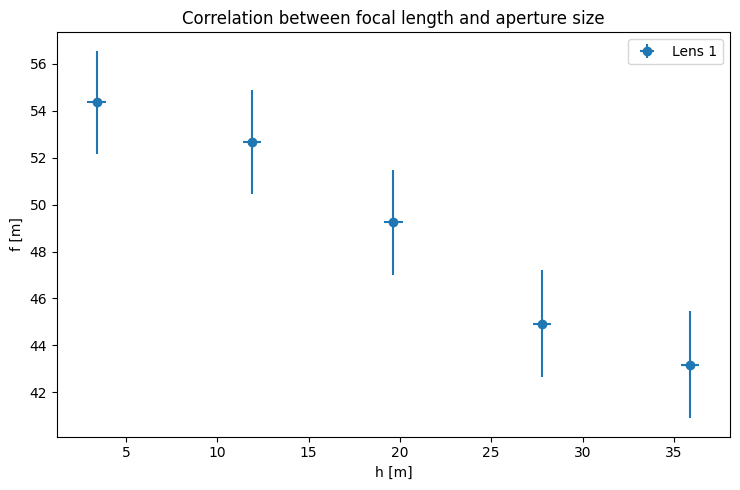

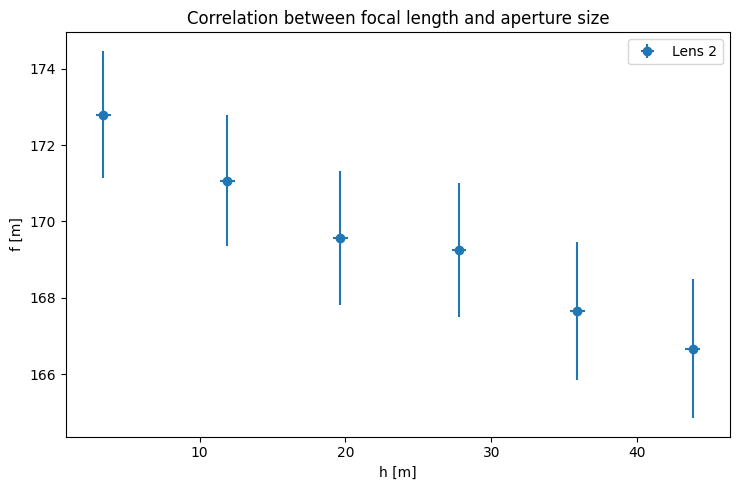

In [103]:
def f_BM_for_SA(lens):
    d = lens[:, 0]
    a = lens[:, 1]
    b = lens[:, 2]
    e = b - a

    return (d**2-e**2)/(4*d)

data_SA = np.loadtxt('SA.txt', delimiter=',')
sigma_h = 0.5

h_u = unumpy.uarray(data_SA[:,0], sigma_h)

d_a_b_1 = unumpy.uarray(data_SA[:5,1:], sigma_master)
d_a_b_2 = unumpy.uarray(data_SA[5:,1:], 5)

f_1_SA= f_BM_for_SA(d_a_b_1)
f_2_SA= f_BM_for_SA(d_a_b_2)

lens_1_SA = np.array([h_u[:5], f_1_SA])
lens_2_SA = np.array([h_u[5:], f_2_SA])

# plot lens 1
plt.figure(figsize=(7.5, 5))
plt.style.use('default')
plt.errorbar(unumpy.nominal_values(lens_1_SA[0]), unumpy.nominal_values(lens_1_SA[1]), xerr=unumpy.std_devs(lens_1_SA[0]), yerr=unumpy.std_devs(lens_1_SA[1]), fmt='o', label='Lens 1')

plt.xlabel('h [m]')
plt.ylabel('f [m]')
plt.title(f'Correlation between focal length and aperture size')
plt.legend(loc='best')
plt.tight_layout()
plt.savefig('Spherical_Aberration_lens_1.png', dpi=600)
plt.show()

# plot lens 2
plt.figure(figsize=(7.5, 5))
plt.style.use('default')
plt.errorbar(unumpy.nominal_values(lens_2_SA[0]), unumpy.nominal_values(lens_2_SA[1]), xerr=unumpy.std_devs(lens_2_SA[0]), yerr=unumpy.std_devs(lens_2_SA[1]), fmt='o', label='Lens 2')

plt.xlabel('h [m]')
plt.ylabel('f [m]')
plt.title(f'Correlation between focal length and aperture size')
plt.legend(loc='best')
plt.tight_layout()
plt.savefig('Spherical_Aberration_lens_2.png', dpi=600)
plt.show()

# Correlation between focal length and aperture size

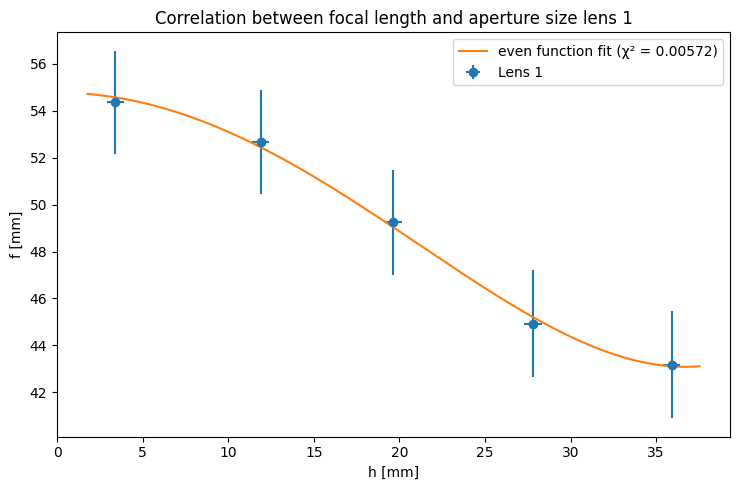

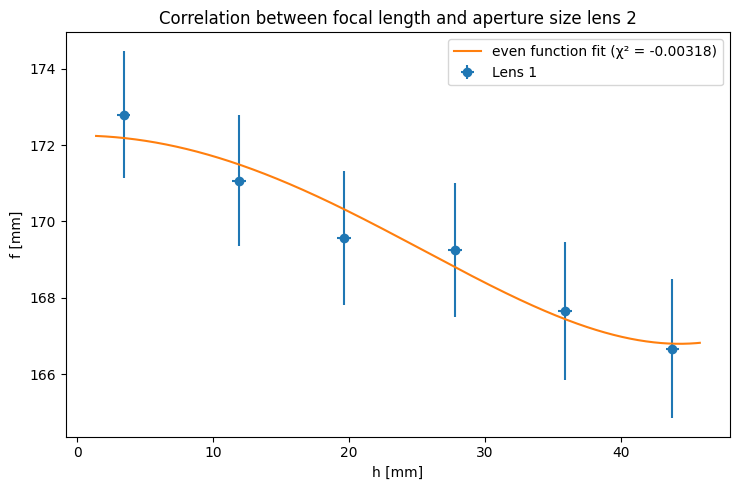

In [106]:
def even_func(beta, h):
    a, b, f0 = beta
    return f0 + a*h**2 + b*h**4

# fit lens 1
model = odr.Model(even_func)
data = odr.RealData(unumpy.nominal_values(lens_1_SA[0]), unumpy.nominal_values(lens_1_SA[1]), sx=unumpy.std_devs(lens_1_SA[1]), sy=unumpy.std_devs(lens_1_SA[1]))
p0 = [1,1,1]
odr_run = odr.ODR(data, model, beta0=p0).run()

a_fit, b_fit, f0_fit = odr_run.beta
a_err, b_err, f0_err = odr_run.sd_beta

a = ufloat(a_fit, a_err)
b = ufloat(b_fit, b_err)
f0 = ufloat(f0_fit, f0_err)

# fit lens 2
data = odr.RealData(unumpy.nominal_values(lens_2_SA[0]), unumpy.nominal_values(lens_2_SA[1]), sx=unumpy.std_devs(lens_2_SA[1]), sy=unumpy.std_devs(lens_2_SA[1]))
odr_run = odr.ODR(data, model, beta0=p0).run()

c_fit, d_fit, g0_fit = odr_run.beta
c_err, d_err, g0_err = odr_run.sd_beta

c = ufloat(c_fit, c_err)
d = ufloat(d_fit, d_err)
g0 = ufloat(g0_fit, g0_err)

# chi2-score
y_hat_lens_1 = even_func([a_fit, b_fit, f0_fit], unumpy.nominal_values(lens_1_SA[0]))
chi2_lens_1 = np.sum((unumpy.nominal_values(lens_1_SA[1]) - y_hat_lens_1) / unumpy.std_devs(lens_1_SA[1])**2)

y_hat_lens_2 = even_func([c_fit, d_fit, g0_fit], unumpy.nominal_values(lens_2_SA[0]))
chi2_lens_2 = np.sum((unumpy.nominal_values(lens_2_SA[1]) - y_hat_lens_2) / unumpy.std_devs(lens_2_SA[1])**2)

# plot lens 1
h_min, h_max = np.min(unumpy.nominal_values(lens_1_SA[0])), np.max(unumpy.nominal_values(lens_1_SA[0]))
h_pad = 0.05 * (h_max - h_min)
h_fit = np.linspace(h_min - h_pad, h_max + h_pad, 1000)

even_func_fit_lens_1 = even_func([a_fit, b_fit, f0_fit], h_fit)

plt.figure(figsize=(7.5, 5))
plt.style.use('default')
plt.errorbar(unumpy.nominal_values(lens_1_SA[0]), unumpy.nominal_values(lens_1_SA[1]), xerr=unumpy.std_devs(lens_1_SA[0]), yerr=unumpy.std_devs(lens_1_SA[1]), fmt='o', label='Lens 1')
plt.plot(h_fit, even_func_fit_lens_1, '-', label=rf"even function fit (χ² = {chi2_lens_1:.5f})")
plt.xlabel('h [mm]')
plt.ylabel('f [mm]')
plt.title(f'Correlation between focal length and aperture size lens 1')
plt.legend(loc='best')
plt.tight_layout()
plt.savefig('Spherical_Aberration_correlation_lens_1.png', dpi=600)
plt.show()

# lens 2
h_min, h_max = np.min(unumpy.nominal_values(lens_2_SA[0])), np.max(unumpy.nominal_values(lens_2_SA[0]))
h_pad = 0.05 * (h_max - h_min)
h_fit = np.linspace(h_min - h_pad, h_max + h_pad, 1000)

even_func_fit_lens_2 = even_func([c_fit, d_fit, g0_fit], h_fit)

plt.figure(figsize=(7.5, 5))
plt.style.use('default')
plt.errorbar(unumpy.nominal_values(lens_2_SA[0]), unumpy.nominal_values(lens_2_SA[1]), xerr=unumpy.std_devs(lens_2_SA[0]), yerr=unumpy.std_devs(lens_2_SA[1]), fmt='o', label='Lens 1')
plt.plot(h_fit, even_func_fit_lens_2, '-', label=rf"even function fit (χ² = {chi2_lens_2:.5f})")
plt.xlabel('h [mm]')
plt.ylabel('f [mm]')
plt.title(f'Correlation between focal length and aperture size lens 2')
plt.legend(loc='best')
plt.tight_layout()
plt.savefig('Spherical_Aberration_correlation_lens_2.png', dpi=600)
plt.show()